In [3]:
import pandas as pd
import numpy as np
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [4]:
df = pd.read_csv("tips.csv")
#df.head()
df.value_counts()




total_bill  tip    sex     smoker  day   time    size
13.00       2.00   Female  Yes     Thur  Lunch   2       2
3.07        1.00   Female  Yes     Sat   Dinner  1       1
22.23       5.00   Male    No      Sun   Dinner  2       1
20.69       2.45   Female  No      Sat   Dinner  4       1
            5.00   Male    No      Sun   Dinner  5       1
                                                        ..
15.53       3.00   Male    Yes     Sat   Dinner  2       1
15.69       1.50   Male    Yes     Sun   Dinner  2       1
            3.00   Male    Yes     Sat   Dinner  3       1
15.77       2.23   Female  No      Sat   Dinner  2       1
50.81       10.00  Male    Yes     Sat   Dinner  3       1
Name: count, Length: 243, dtype: int64

<Axes: >

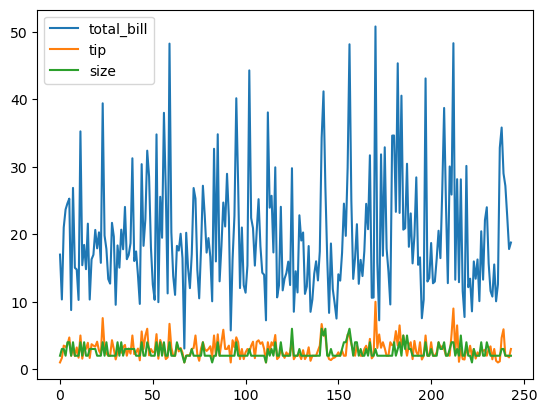

In [5]:
df.plot()

In [6]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [7]:
px.scatter(df,x = "total_bill",y="tip",color = "sex")

In [8]:
px.pie(df,names="sex")

array([[<Axes: title={'center': 'total_bill'}>,
        <Axes: title={'center': 'tip'}>],
       [<Axes: title={'center': 'size'}>, <Axes: >]], dtype=object)

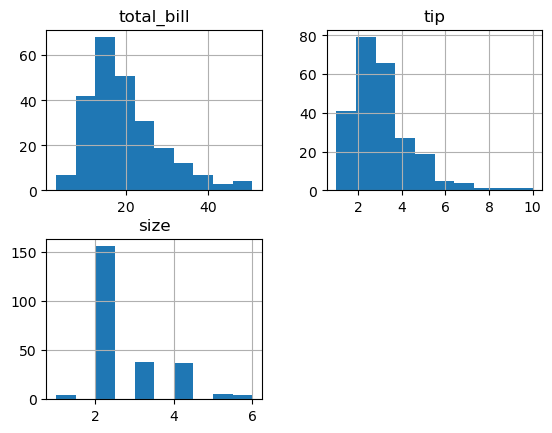

In [9]:
df.hist()

<Axes: >

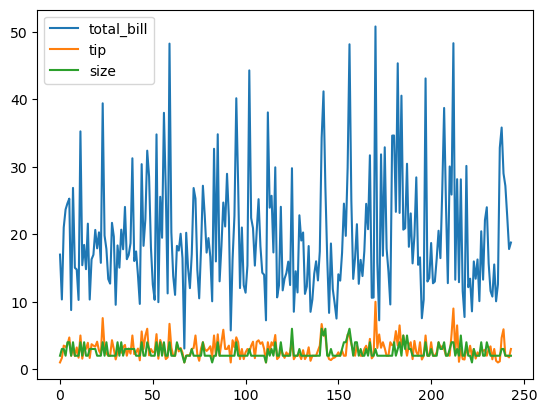

In [10]:
df.plot()

In [11]:
df = pd.get_dummies(df,drop_first = True)

In [12]:
X = df.drop("tip",axis= 1)
y = df["tip"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11
)

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
model.score(X_test, y_test)

0.6160453998996112

In [16]:
example = X_test.iloc[0:18]
model.predict(example)

array([4.12163465, 2.7424606 , 2.92986096, 2.6777345 , 3.32149526,
       2.34170999, 4.14669005, 2.17556997, 2.82913554, 3.38167165,
       2.74059559, 3.56997645, 2.50285144, 2.1577721 , 2.27047445,
       2.83659994, 1.6705767 , 2.41348588])

In [17]:
model.score(X_test, y_test)

0.6160453998996112

In [ ]:
from sklearn.metrics import mean_absolute_error
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.5474409041050161




This project predicts the tip amount given to a waiter based on several restaurant-related features.
# Dataset features
* total_bill: the total bill
* tip: tip given to waiter in dollars
* sex: gender of the person paying the bill
* smoker: whether person smoked or not
* day: day of the week
* time: lunch or dinner
* size: number of people
# Model
Linear Regression was used because there is a linear relationship between **total_bill** and **tip**. The model predicts the tip amount using the provided instances.
The dataset was split into **80% training** and **20% testing** data.

# Libraries and Functions

1. **NumPy**
   Used for numerical operations and working with arrays.

2. **Pandas**
   Used for:

* Loading dataset (`pd.read_csv`)
* Data manipulation
* Encoding categorical variables (`pd.get_dummies`)
* Creating new data for prediction (`pd.DataFrame`)

3. **Plotly Express**
   Used for data visualization:

* `px.scatter()` → visualize the relationship between **total_bill** and **tip**
* `px.pie()` → show distribution of categorical variables

4. **Scikit-Learn**
   Used for machine learning:

* `train_test_split()` → split dataset into training and testing sets
* `LinearRegression()` → regression model
* `model.fit()` → train the model
* `model.score()` → calculate R² score
* `model.predict()` → predict tip amount

# Model Evaluation

The model achieved an **R² score of 0.6160**, meaning it explains approximately **61.6% of the variance** in tip amounts.
R² = **0.6160453998996112**
The model’s **mean absolute error (MAE)** is **0.5474**, which means that on average the predicted tip differs from the actual tip by about **$0.55**.
MAE = **0.5474409041050161**
# Prediction Example

new_data = pd.DataFrame({
    "total_bill": [25.0],
    "size": [2],
    "sex_Male": [0],
    "smoker_Yes": [0],
    "day_Sat": [1],
    "day_Sun": [0],
    "day_Thur": [0],
    "time_Dinner": [1]
})
**Predicted Tip:** **3.4591255575825657**
